1. Install dependencies

In [1]:
!pip install tensorflow tensorflow-gpu opencv-python matplotlib

  Using cached protobuf-5.29.4-cp310-abi3-win_amd64.whl.metadata (592 bytes)
  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.9.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached numpy-2.1.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
INFO: pip is looking at multiple versions of tensorflow-gpu to determine which version is compatible with other requirements. This could take a while.
  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


ERROR: Requested tensorflow-gpu from https://files.pythonhosted.org/packages/8a/45/fa31ced1db38f9424f262dfbf35747fe5378b5c808cecb373c8cb8e515d3/tensorflow-gpu-2.12.0.tar.gz has invalid metadata: Expected end or semicolon (after name and no valid version specifier)
    python_version>"3.7"
                  ^


In [2]:
!pip list

Package                      Version
---------------------------- --------------
absl-py                      2.2.2
anyio                        4.9.0
argon2-cffi                  23.1.0
argon2-cffi-bindings         21.2.0
arrow                        1.3.0
asttokens                    3.0.0
astunparse                   1.6.3
async-lru                    2.0.5
attrs                        25.3.0
babel                        2.17.0
beautifulsoup4               4.13.3
bleach                       6.2.0
cachetools                   5.5.2
certifi                      2025.1.31
cffi                         1.17.1
charset-normalizer           3.4.1
colorama                     0.4.6
comm                         0.2.2
contourpy                    1.3.1
cycler                       0.12.1
debugpy                      1.8.13
decorator                    5.2.1
defusedxml                   0.7.1
exceptiongroup               1.2.2
executing                    2.2.0
fastjsonschema               2.2

In [2]:
import tensorflow as tf
import os

In [3]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [4]:
tf.config.list_physical_devices('GPU')

[]

2. REMOVE DODGY IMAGES

In [5]:
import cv2
import imghdr

In [6]:
data_dir = 'data'

In [7]:
image_exts = ['jpg', 'jpeg', 'png', 'bmp', 'webp'] # creating a class to allow only these images

In [8]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))
            #os.remove(image_path)

3. Load Data

In [ ]:
tf.data.Dataset??

In [9]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
tf.keras.utils.image_dataset_from_directory?? #used to pre-process the image dataset, like lableling it etc.

In [10]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 164 files belonging to 2 classes.


In [11]:
data_iterator = data.as_numpy_iterator()

In [12]:
batch = data_iterator.next()

In [13]:
# Images represented as numpy arrays
batch[0].shape

(32, 256, 256, 3)

In [14]:
# class 1 = sad, class 0 = happy
batch[1]

array([0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 1])

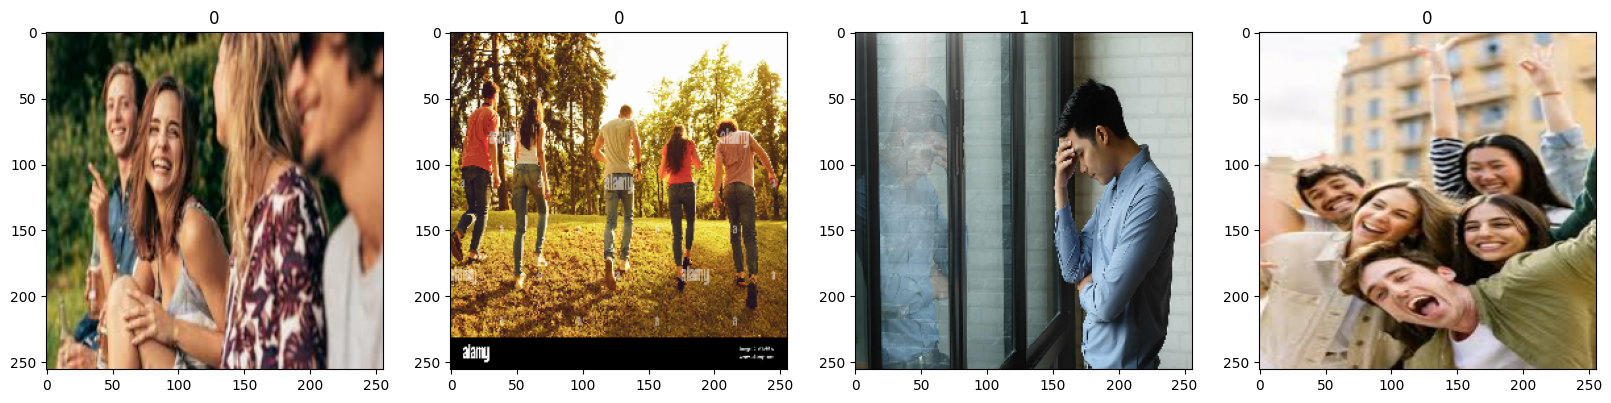

In [15]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

4. Scale Data

In [16]:
data = data.map(lambda x,y: (x/255, y))

In [17]:
data.as_numpy_iterator().next()

(array([[[[7.56265342e-01, 8.11167300e-01, 8.18121910e-01],
          [7.69868255e-01, 8.24770212e-01, 8.31724882e-01],
          [7.92616189e-01, 8.47518146e-01, 8.54472816e-01],
          ...,
          [4.07261282e-01, 9.28617567e-02, 8.89401883e-02],
          [3.73241723e-01, 8.43963027e-02, 7.21813738e-02],
          [3.61672789e-01, 7.60263503e-02, 6.27451017e-02]],
 
         [[7.41948366e-01, 7.96850324e-01, 8.08615029e-01],
          [7.57386208e-01, 8.12288165e-01, 8.24052870e-01],
          [7.68673420e-01, 8.23575377e-01, 8.35340083e-01],
          ...,
          [4.01240081e-01, 8.68405774e-02, 8.29190090e-02],
          [3.61213237e-01, 8.51102918e-02, 6.82598054e-02],
          [3.48391533e-01, 7.90594369e-02, 5.88235296e-02]],
 
         [[7.29733229e-01, 7.80713618e-01, 8.04243028e-01],
          [7.38756835e-01, 7.89737225e-01, 8.13266635e-01],
          [7.52941191e-01, 8.03921580e-01, 8.27450991e-01],
          ...,
          [3.94394577e-01, 7.99950659e-02, 7.6073

5. Split Data

In [19]:
train_size = int(len(data)*0.7)
val_size = int(len(data)*0.2)
test_size = int(len(data)*0.1)

In [20]:
train_size

4

In [21]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)